# 🛠️ Travail à réaliser

## Partie 1 — Préparation et exploration des données

- Charger et explorer le dataset.
- Identifier les principales caractéristiques des données.
- Réaliser le nettoyage nécessaire.
- Traiter les données manquantes, invalides ou incohérentes.
- Effectuer les analyses exploratoires nécessaires à la compréhension des données.
- Justifier les principales décisions prises lors de la préparation.

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score, KFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score,mean_squared_error
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)


In [ ]:
df = pd.read_excel('../data/data.xlsx')


In [15]:

print(df.dtypes)
print(df.duplicated)


print(df.columns)
print(df.head())
print(df.columns)
print(df.describe)
print(df[df.isnull()])
print(df.shape)
print(df.duplicated())
# df = df.dropna()
# df = df.drop_duplicates()
print(df.shape)
print(df["InvoiceNo"].dtypes)
print(df["StockCode"].dtypes)
print(df["Description"].dtypes)
print(df["Quantity"].dtypes)
print(df["UnitPrice"].dtypes)
print(df["CustomerID"].dtypes)
print(df["Country"].dtypes)

InvoiceNo              object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[us]
UnitPrice             float64
CustomerID            float64
Country                   str
dtype: object
<bound method DataFrame.duplicated of        InvoiceNo StockCode                          Description  Quantity  \
0         536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1         536365     71053                  WHITE METAL LANTERN         6   
2         536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3         536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4         536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   
...          ...       ...                                  ...       ...   
541904    581587     22613          PACK OF 20 SPACEBOY NAPKINS        12   
541905    581587     22899         CHILDREN'S APRON DOLLY GIRL          6   
541906    58158

In [16]:
columns=['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country']

numerique_columns=['Quantity','UnitPrice', 'CustomerID']
non_numerique_columns=['InvoiceNo','StockCode','Description']


In [17]:
df.isna().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [18]:
def negative_null(df, columns):
    for d in columns:
        negative = (df[d] < 0).sum()
        null = df[d].isnull().sum()

        print(f"Nombre de valeurs negatives dans {d} : {negative}")
        print(f"Nombre de valeurs null dans {d} : {null}\n")
        df[d] = df[d].abs()
        


In [19]:
negative_null(df,numerique_columns)


Nombre de valeurs negatives dans Quantity : 10624
Nombre de valeurs null dans Quantity : 0

Nombre de valeurs negatives dans UnitPrice : 2
Nombre de valeurs null dans UnitPrice : 0

Nombre de valeurs negatives dans CustomerID : 0
Nombre de valeurs null dans CustomerID : 135080



In [20]:
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

snapshot_date = df["InvoiceDate"].max() + pd.Timedelta(days=1)
print(snapshot_date)

2011-12-10 12:50:00


In [21]:
df["TotalPrice"] = df["Quantity"] * df["UnitPrice"]


# Partie 2 — Construction des indicateurs RFM

Transformer les données transactionnelles afin d'obtenir **une ligne par client**.

Construire les trois indicateurs RFM :

- **Recency (Récence)** : nombre de jours depuis le dernier achat ;
- **Frequency (Fréquence)** : fréquence des achats du client ;
- **Monetary (Montant)** : montant total dépensé par le client.

La table finale devra permettre d'obtenir, au minimum :

`CustomerID | Recence | Frequence | Montant`

Vous devrez expliquer la signification de ces trois indicateurs et leur intérêt pour la segmentation des clients.

---

In [22]:
rfm = df.groupby("CustomerID").agg({
    "InvoiceDate": lambda x: (snapshot_date - x.max()).days,
    "InvoiceNo": "nunique", 
    "TotalPrice": "sum"
})

rfm.columns = ["Recency", "Frequency", "Monetary"]

print(rfm.head())

            Recency  Frequency   Monetary
CustomerID                               
12346.0         326          2  154367.20
12347.0           2          7    4310.00
12348.0          75          4    1797.24
12349.0          19          1    1757.55
12350.0         310          1     334.40


# Partie 3 — Préparation des variables pour le clustering

Analyser les distributions des variables RFM et identifier les éventuelles particularités pouvant influencer le clustering.

Appliquer, si nécessaire, les transformations et méthodes de normalisation ou de standardisation adaptées.

Justifier les principales étapes de préparation des variables avant l'utilisation de K-Means.

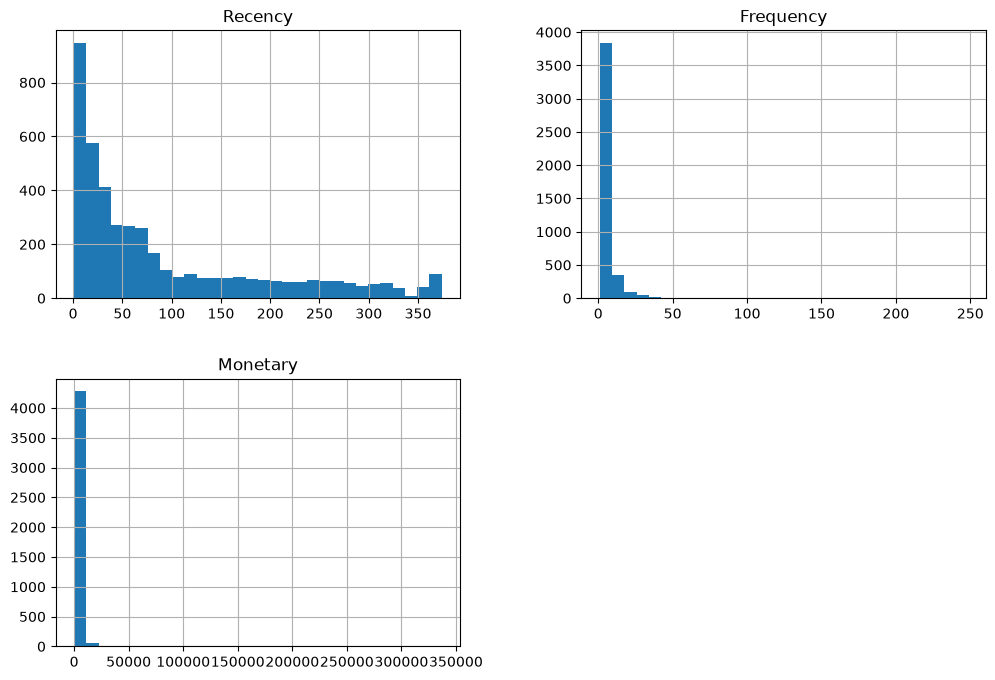

In [23]:
import matplotlib.pyplot as plt


rfm.hist(bins=30, figsize=(12, 8))
plt.xlabel("Jours")
plt.ylabel("clients")
plt.show()

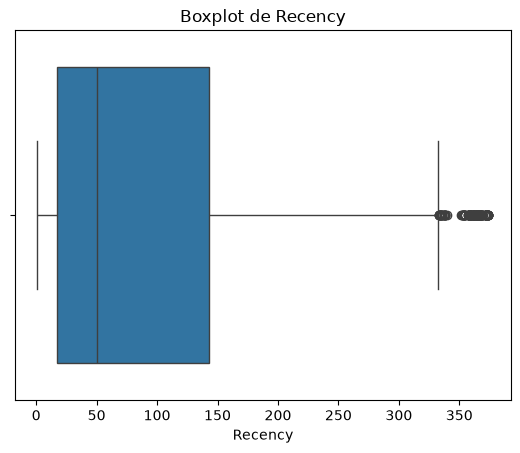

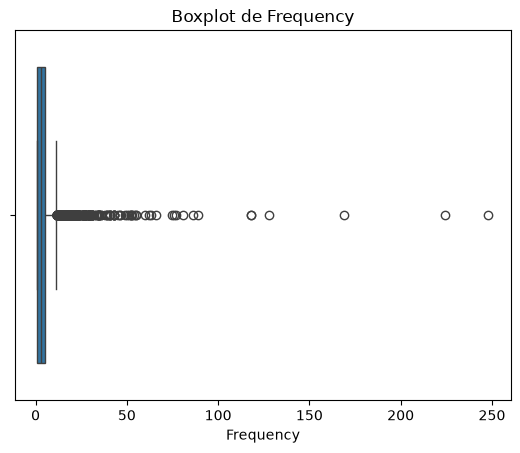

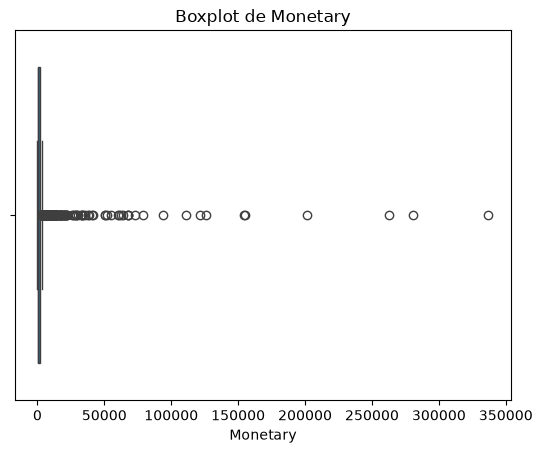

In [24]:
import seaborn as sns
for col in ["Recency", "Frequency", "Monetary"]:
    sns.boxplot(x=rfm[col])
    plt.title(f"Boxplot de {col}")
    plt.show()

In [25]:
df = df[~df["InvoiceNo"].astype(str).str.startswith("C")]



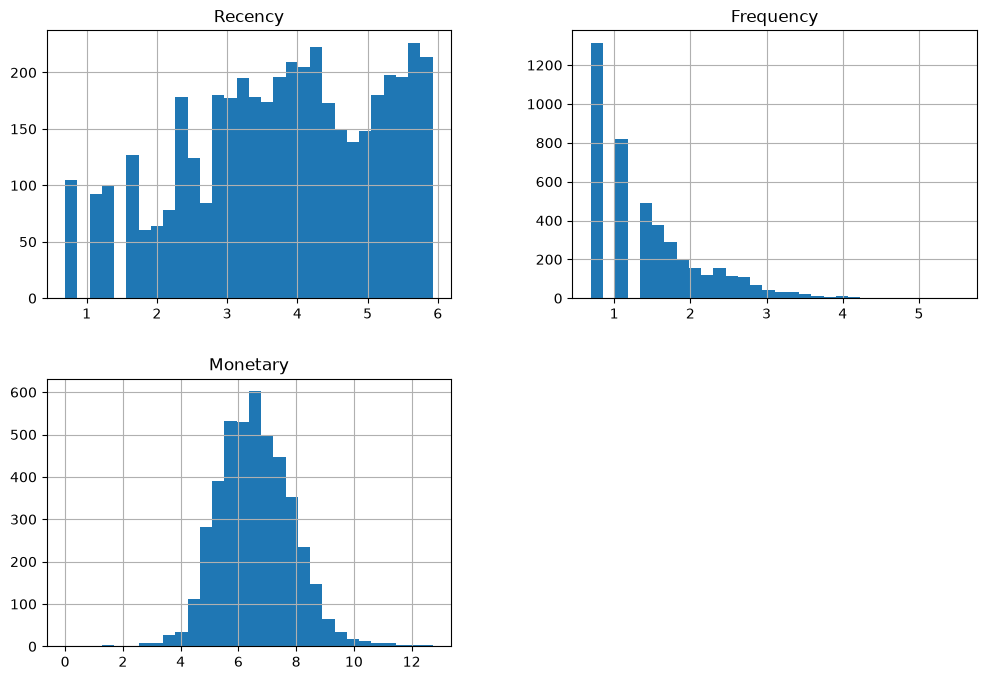

In [26]:
import numpy as np
from sklearn.preprocessing import StandardScaler

rfm_log = np.log1p(rfm)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(rfm_log)

rfm_log.hist(bins=30, figsize=(12, 8))

plt.show()

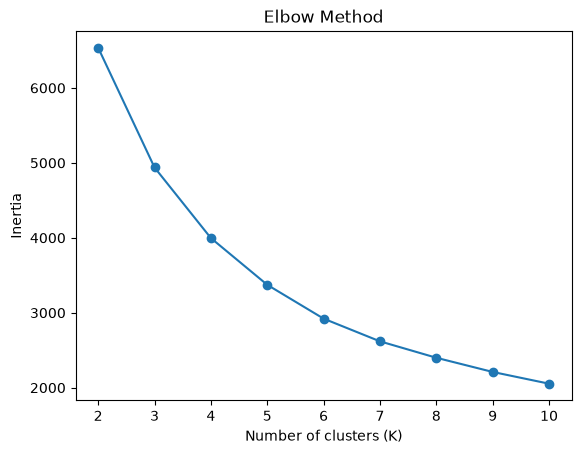

In [27]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# Elbow method
inertias = []

for k in range(2, 11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)

plt.plot(range(2, 11), inertias, marker="o")
plt.xlabel("Number of clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

In [34]:
from sklearn.metrics import silhouette_score
# silhouette_score methode
score = silhouette_score(
    X_scaled,
    rfm["Cluster"]
)

print("Silhouette Score:", score)

Silhouette Score: 0.33439732986631365


In [39]:
final_k=3
kmeans = KMeans(n_clusters=final_k, random_state=42, n_init=10)

rfm["Cluster"] = kmeans.fit_predict(X_scaled)
centroids = kmeans.cluster_centers_

print(rfm)
print(centroids)

            Recency  Frequency   Monetary  Cluster                  type
CustomerID                                                              
12346.0         326          2  154367.20        0       Clients fidèles
12347.0           2          7    4310.00        0       Clients fidèles
12348.0          75          4    1797.24        1      Clients inactifs
12349.0          19          1    1757.55        1      Clients inactifs
12350.0         310          1     334.40        2  Clients occasionnels
...             ...        ...        ...      ...                   ...
18280.0         278          1     180.60        2  Clients occasionnels
18281.0         181          1      80.82        2  Clients occasionnels
18282.0           8          3     179.50        1      Clients inactifs
18283.0           4         16    2094.88        0       Clients fidèles
18287.0          43          3    1837.28        1      Clients inactifs

[4372 rows x 5 columns]
[[-1.14168234  1.61547761 

4-3-2. Analyser les caractéristiques des clusters

In [29]:
print(rfm["Cluster"].value_counts().sort_index())

cluster_summary = rfm.groupby("Cluster")[
    ["Recency", "Frequency", "Monetary"]
].mean().round(2)

print(cluster_summary)

Cluster
0     774
1    1729
2    1869
Name: count, dtype: int64
         Recency  Frequency  Monetary
Cluster                              
0          15.68      16.21   8667.92
1          44.43       3.97   1240.86
2         167.72       1.49    357.59


In [30]:
rfm["type"] = rfm["Cluster"].map({
    0: "Clients fidèles",
    1: "Clients inactifs",
    2: "Clients occasionnels"
})

In [ ]:
# DBSCAN
from sklearn.cluster import DBSCAN


dbscan = DBSCAN(
    eps=0.5,
    min_samples=5
)

labels = dbscan.fit_predict(X_scaled)

rfm["DBSCAN_Cluster"] = labels




1270


In [61]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)
print(X_pca)


pca_df = pd.DataFrame(
    X_pca,
    columns=["PC1", "PC2"]
)

pca_df["Cluster"] = rfm["Cluster"].values
pca_df["DBSCAN_Cluster"]=rfm["DBSCAN_Cluster"].values

print(pca_df.head())

[[ 1.44750461  2.93576386]
 [ 2.36446487 -0.83840516]
 [ 0.35771377  0.70146001]
 ...
 [-0.09653018 -1.49772573]
 [ 2.47027527 -0.47965523]
 [ 0.38546197  0.28338116]]
        PC1       PC2  Cluster  DBSCAN_Cluster
0  1.447505  2.935764        0              -1
1  2.364465 -0.838405        0               0
2  0.357714  0.701460        1               0
3  0.079509 -0.486521        1               1
4 -1.713958  0.660419        2               1


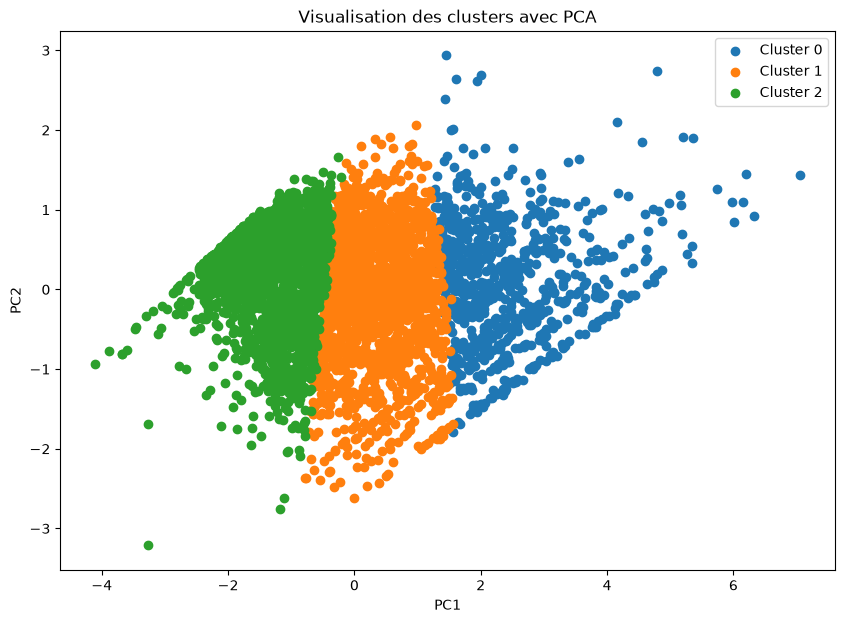

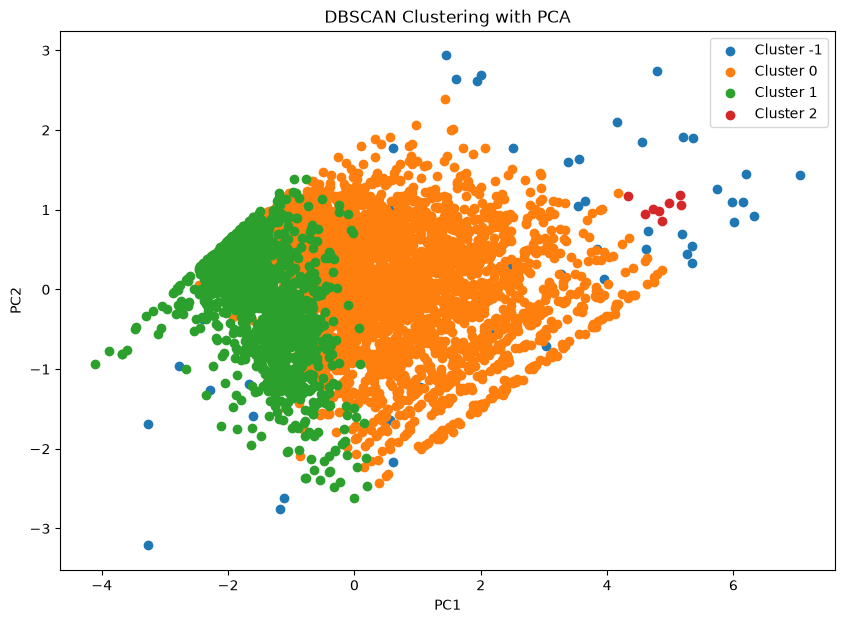

In [69]:
plt.figure(figsize=(10, 7))

rfm_group = pca_df.groupby("Cluster")

for cluster, data in rfm_group:
    plt.scatter(
        data["PC1"],
        data["PC2"],
        label=f"Cluster {cluster}"

    )

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Visualisation des clusters avec PCA")
plt.legend()
plt.show()

# Visualize DBSCAN with your PCA
plt.figure(figsize=(10, 7))

for cluster, data in pca_df.groupby("DBSCAN_Cluster"):

    plt.scatter(
        data["PC1"],
        data["PC2"],
        label=f"Cluster {cluster}"

       
    )

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("DBSCAN Clustering with PCA")
plt.legend()
plt.show()

In [ ]:
X = rfm[["Recency", "Frequency", "Monetary"]]
y=rfm["Cluster"]
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42, test_size=0.20, shuffle=True)



model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
pipeline = Pipeline([
            
            ("model",model)
            
        ])
pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)


print(f"R²   : {r2_score(y_test, y_pred):.4f}")
print(f"MAE  : {mean_absolute_error(y_test, y_pred):.2f}")
print(f"MSE  : {mean_squared_error(y_test, y_pred):.2f}")
print(f"RMSE : {root_mean_squared_error(y_test, y_pred):.2f}")

x_train :             Recency  Frequency  Monetary
CustomerID                              
15820.0         320          1    206.98
13239.0         262          1    329.56
16178.0         138          1    197.90
12596.0          51          2    618.27
15757.0          66          2    714.42
...             ...        ...       ...
17007.0          51          7    902.43
12942.0         131          3    683.90
16527.0          81          1    228.06
17466.0          10          2    763.28
13489.0         105          4    449.52

[3497 rows x 3 columns]
R²   : 0.9356
MAE  : 0.03
MSE  : 0.03
RMSE : 0.19


In [ ]:


#Accuracy:  The proportion of correct predictions among all predictions.
accuracy = accuracy_score(y_test, y_pred)

# Precision -> It answers: Among the clients that the Random Forest predicted as a particular cluster, how many actually belong to that cluster?
precision = precision_score(
    y_test,
    y_pred,
    average="weighted"
)

# Recall -> It answers : Among all clients that actually belong to a particular cluster, how many did the Random Forest correctly identify?

recall = recall_score(
    y_test,
    y_pred,
    average="weighted"
)

# F1-score is a balance between Precision and Recall.
f1 = f1_score(
    y_test,
    y_pred,
    average="weighted"
)

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1-score :", f1)

Accuracy : 0.9657142857142857
Precision: 0.9660662873038564
Recall   : 0.9657142857142857
F1-score : 0.965719237096275


In [54]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    model,
    X_train,
    y_train,
    cv=5,
    scoring="accuracy"
)

print("Scores of the 5 folds:", cv_scores)
print("Mean Accuracy:", cv_scores.mean())
print("Standard Deviation:", cv_scores.std())

Scores of the 5 folds: [0.97857143 0.98142857 0.98426323 0.97711016 0.97854077]
Mean Accuracy: 0.9799828326180258
Standard Deviation: 0.002558743892425952
